<a href="https://colab.research.google.com/github/yaelmasterpro09-code/Equipo-8_Int.-Artificial-y-Redes-Neuronales_FIME_UANL/blob/main/AF7_Redes_Neuronales_Artificiales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AF7: Redes Neuronales Artificiales

Datos de Equipo :

Edgar Yael Martínez Pérez-
2050426


Edwin Magdaleno- Domínguez 2177965

Patricio Israel Gómez Martínez - 2062237 - N5

Giann Luca Verdeja Briones - 2050452

Materia: Inteligencia Artificial
Hora: V6



1.- Importar librerias

In [ ]:
#importar librerias
import numpy as np
import keras
from keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


2.-Cargar datos

In [ ]:
#carga de datos y division en datos de prueba y entrenamiento
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

3.-Preprocesamiento de datos.

In [ ]:
#normalizacion de los valores de los datos de prueba y de entrenamiento, en valores de 0 a 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [ ]:
# agregar una dimension extra a los datos
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)



In [ ]:
#visualizacion de la dimension de los datos
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "ejemplos de entrenamiento")
print(x_test.shape[0], "ejemplos de prueba")


x_train shape: (60000, 28, 28, 1)
60000 ejemplos de entrenamiento
10000 ejemplos de prueba


In [ ]:
# clasifica las etiquetas en 10 clases
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

4.-Selección y entrenamiento del modelo

In [ ]:
# construccion del modelo
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28, 1]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento del modelo
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9216 - loss: 0.2781 - val_accuracy: 0.9662 - val_loss: 0.1188
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9684 - loss: 0.1050 - val_accuracy: 0.9777 - val_loss: 0.0765
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9786 - loss: 0.0687 - val_accuracy: 0.9753 - val_loss: 0.0766
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9798 - val_loss: 0.0714
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9891 - loss: 0.0351 - val_accuracy: 0.9812 - val_loss: 0.0673
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9924 - loss: 0.0252 - val_accuracy: 0.9808 - val_loss: 0.0717
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9939 - loss: 0.0201 - val_accuracy: 0.9840 - val_loss: 0.0639
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 

In [ ]:
#conversion del vetor de la etiqueta al numero correspondiente
i=0
etiquetas=['cero','uno','dos','tres','cuatro','cinco','seis','siete','ocho','nueve']
valor_train=np.argmax(y_train[i])
valor_test=np.argmax(y_test[i])

In [ ]:
#evaluacion del modelo con los valores de prueba
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.07505527883768082
Test accuracy: 0.9821000099182129


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


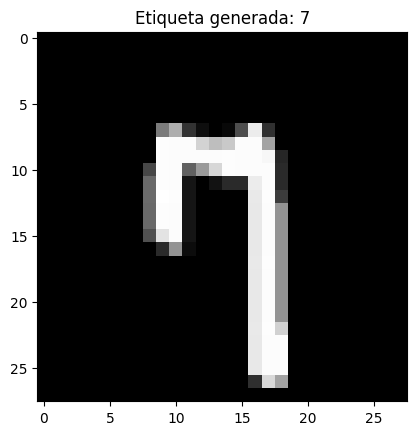

In [ ]:
#grafica de prueba 1 con la imagen i del conjunto de datos de entrenamiento
i=80
model.predict(x_test[i].reshape(-1,28,28))
prueba1=model.predict(x_test[i].reshape(-1,28,28))
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Etiqueta generada: {np.argmax(prueba1)}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[5.4732111e-14 4.9822257e-11 2.7255770e-10 8.6286867e-14 9.9999011e-01
  5.1505383e-14 5.7357636e-15 7.3485159e-12 1.3644412e-11 9.9463759e-06]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Etiqueta supuesta: 4
Etiqueta real:
4


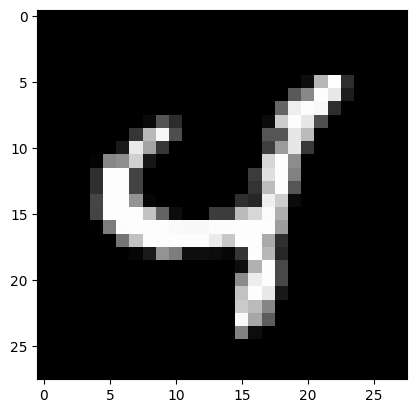

In [ ]:
#prueba 2 con imagen 67, del conjunto de imagenes de prueba
u=67
print(model.predict(x_test[u].reshape(-1,28,28)))
prueba=model.predict(x_test[u].reshape(-1,28,28))
print("Etiqueta supuesta:", np.argmax(prueba))
print("Etiqueta real:")
valre=valor_test=np.argmax(y_test[u])
print(valre)
plt.imshow(x_test[u], cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[9.99999523e-01 1.32052397e-10 1.18180505e-08 4.30934498e-12
  1.84520679e-13 2.37955966e-09 4.10158634e-07 5.16742371e-10
  3.69858277e-09 2.24098713e-08]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Etiqueta supuesta: 0
Etiqueta real:
0


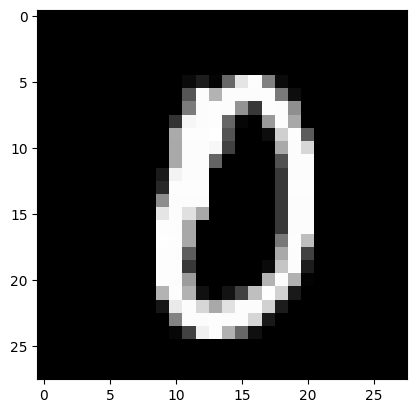

In [ ]:
#prueba 3 con imagen 55, del conjunto de imagenes de prueba
u=55
print(model.predict(x_test[u].reshape(-1,28,28)))
prueba=model.predict(x_test[u].reshape(-1,28,28))
print("Etiqueta supuesta:", np.argmax(prueba))
print("Etiqueta real:")
valre=valor_test=np.argmax(y_test[u])
print(valre)
plt.imshow(x_test[u], cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[7.69083215e-07 7.28458960e-11 8.83100093e-10 1.30930735e-11
  8.59892279e-12 7.03779124e-09 9.99999285e-01 1.04694888e-12
  1.39432343e-09 5.82270733e-12]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Etiqueta supuesta: 6
Etiqueta real:
6


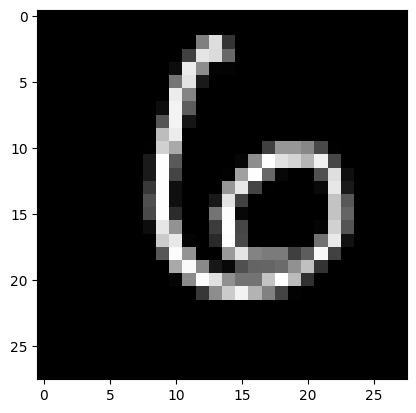

In [ ]:
#prueba 4 con imagen 6, del conjunto de imagenes de prueba
u=100
print(model.predict(x_test[u].reshape(-1,28,28)))
prueba=model.predict(x_test[u].reshape(-1,28,28))
print("Etiqueta supuesta:", np.argmax(prueba))
print("Etiqueta real:")
valre=valor_test=np.argmax(y_test[u])
print(valre)
plt.imshow(x_test[u], cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[7.69083215e-07 7.28458960e-11 8.83100093e-10 1.30930735e-11
  8.59892279e-12 7.03779124e-09 9.99999285e-01 1.04694888e-12
  1.39432343e-09 5.82270733e-12]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Etiqueta supuesta: 6
Etiqueta real:
6


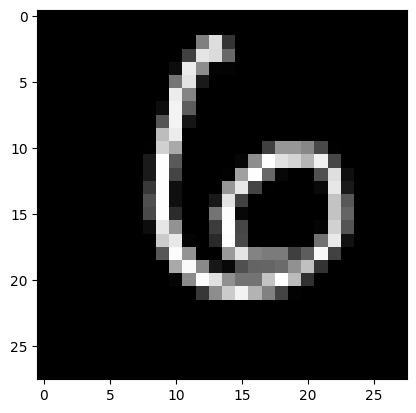

In [ ]:
#prueba 5 con imagen 6, del conjunto de imagenes de prueba
u=100
print(model.predict(x_test[u].reshape(-1,28,28)))
prueba=model.predict(x_test[u].reshape(-1,28,28))
print("Etiqueta supuesta:", np.argmax(prueba))
print("Etiqueta real:")
valre=valor_test=np.argmax(y_test[u])
print(valre)
plt.imshow(x_test[u], cmap='gray')
plt.show()